In [1]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
from utils.ica_pipeline import preprocess_for_ica, detrend_and_iir_bandpass
from utils.epoch_and_average import revise_annot, eeglab_logic_bin_epoch
from utils.deconv_pipeline import (build_design,
                                   nested_cv, refit,
                                   loop_over_subjs, refit_all_subjs,
                                   compare_model_fit,
                                   get_time_window_coefs,
                                   time_window_heatmap)
import mne

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
import seaborn as sns

import time
import math
import re
from collections import namedtuple
from typing import Callable


from scipy.stats import ttest_1samp, mode, pearsonr
from statsmodels.stats.multitest import fdrcorrection

from collections import OrderedDict
from IPython.display import clear_output
import warnings

### Epoching and setting/checking parameters

In [2]:
WEIHUN_DIR = "/Users/jowanglin/regression-based_ERP/data/eeg/weihun"
CRYSTAL_DIR = "/Users/jowanglin/regression-based_ERP/data/eeg/crystal"
WEIHUN_RESULTS = "/Users/jowanglin/regression-based_ERP/results/weihun"
CRYSTAL_RESULTS = "/Users/jowanglin/regression-based_ERP/results/crystal"

warnings.filterwarnings("ignore")

raw_file_name = f"subj{str(4).zfill(3)}_EML_YA_run01-12.set"
raw = mne.io.read_raw_eeglab(f"{WEIHUN_DIR}/{raw_file_name}", verbose=False, preload=False)
df_annot = pd.DataFrame(raw.annotations)

fixation = "210"
non_final = "222"
neu = ("235", "236", "237", "238")
pos = ("231", "232")
neg = ("233", "234")
annot_revised = revise_annot(df_annot,
                             fixation=fixation,
                             non_final=non_final,
                             codes_after_fixation_are_final=True,
                             transform_description=lambda arr: [a.replace("boundary", "edge") for a in arr],
                             pos=pos, neu=neu, neg=neg)
df_annot_revised = pd.DataFrame(annot_revised)

indices_w6 = np.asarray(df_annot_revised.loc[df_annot_revised["description"].str.contains("w6/")].index)
indices_w7 = np.asarray(df_annot_revised.loc[df_annot_revised["description"].str.contains("w7/")].index)
indices_w1_bads = np.sort(np.array([i for i in (set(indices_w6 + 1) - set(indices_w7))])) - 6
df_annot_revised.loc[indices_w1_bads, "description"] = df_annot_revised.iloc[indices_w1_bads]["description"].map(lambda x: "BAD"+x)
display(df_annot_revised.iloc[indices_w1_bads])
annot_revised_with_bads = mne.Annotations(onset=df_annot_revised["onset"],
                                          duration=df_annot_revised["duration"],
                                          description=df_annot_revised["description"])
raw.set_annotations(annot_revised_with_bads)
total_n_trials = len([s for s in list(df_annot_revised["description"]) if s.startswith("w1/")])
print(f"TOTAL # TRIALS = {total_n_trials} trials")

SOA = mode(np.diff(df_annot["onset"].to_numpy())).mode
print(f"SOA = {SOA} seconds")
DOWNSAMPLE_SFREQ = 100.0  
N_WORDS = 7

RIDGE_TOL = 1e-5
MAX_ITER = 20000
RANDOM_STATE = 42
DROP_PERCENTAGE_THRESHOLD = 20

ch_roi = ["CZ", "C3", "C4", "CP3", "CP4", "CPZ"]
alpha_range = np.logspace(-3, 3, 25)  # 0.001 -> 1000

,onset,duration,description,orig_time,extras
854,750.103,0.0,BADw1/neu,None,{}
1432,1235.362,0.0,BADw1/neu,None,{}
1864,1653.040,0.0,BADw1/pos,None,{}
2870,2496.794,0.0,BADw1/pos,None,{}


TOTAL # TRIALS = 204 trials
SOA = 0.36599999999998545 seconds


In [3]:
conditions_list = [dict(neu=("235", "236", "237", "238"),
                        pos=("231", "232"),
                        neg=("233", "234"))]
epochs_list = eeglab_logic_bin_epoch(raw,
                                     fixation,
                                     non_final,
                                     position_range=(1, 7), 
                                     conditions_list=conditions_list,
                                     revise_annotations=False,
                                     tmin=0.0, tmax=SOA*N_WORDS,
                                     baseline=None,
                                     reject_peak_to_peak=None,  # don't drop trials here yet                  
                                     decim=10)
clear_output()

epochs = epochs_list[0]
display(epochs)

<Epochs | 1448 events (all good), 0 – 2.56 s (baseline off), ~93.7 MiB, data loaded,
 np.str_('w1/neg'): 52
 np.str_('w1/neu'): 102
 np.str_('w1/pos'): 50
 np.str_('w2/neg'): 52
 np.str_('w2/neu'): 104
 np.str_('w2/pos'): 52
 np.str_('w3/neg'): 52
 np.str_('w3/neu'): 104
 np.str_('w3/pos'): 52
 np.str_('w4/neg'): 52
 and 11 more events ...>

In [4]:
warnings.resetwarnings()

# design matrix condition number turns out to be 100 (so model's condition number is 10^4)
# thus making Ridge regression defensible

matrix_with_word_pos = build_design(soa=SOA,
                                    sfreq=DOWNSAMPLE_SFREQ,
                                    n_words=N_WORDS, n_trials=total_n_trials,
                                    response_lag=0.7,
                                    rank_tol=1e-2,
                                    intercept=True,
                                    verbose=True,
                                    word_pos=np.vstack([np.log(np.arange(1, N_WORDS+1)) for _ in range(total_n_trials)]))
print(f"X_full.shape = {matrix_with_word_pos.full.shape}")
print(f"rank = {matrix_with_word_pos.rank}")
print(f"condition number = {matrix_with_word_pos.condition_num}")
print(f"5 largest singular values: {matrix_with_word_pos.singular_vals[:5]}")
print(f"5 smallest singular values: {matrix_with_word_pos.singular_vals[-5:]}\n")

matrix_intercept_only = build_design(soa=SOA,
                                     sfreq=DOWNSAMPLE_SFREQ,
                                     n_words=N_WORDS, n_trials=total_n_trials,
                                     response_lag=0.7,
                                     rank_tol=1e-2,
                                     intercept=True,
                                     verbose=True)
print(f"X_intercept = shape = {matrix_intercept_only.full.shape}")
print(f"rank = {matrix_intercept_only.rank}")
print(f"condition number = {matrix_intercept_only.condition_num}")
print(f"5 largest singular values: {matrix_intercept_only.singular_vals[:5]}")
print(f"5 smallest singular values: {matrix_intercept_only.singular_vals[-5:]}\n")

del matrix_with_word_pos
del matrix_intercept_only

# time samples per trial = 257
response to each sampled time point lasts 70 time points
X_full.shape = (52428, 140)
rank = 140
condition number = 100.93671892253451
5 largest singular values: [82.57738594 82.57738594 82.57738594 82.57738594 82.57738594]
5 smallest singular values: [0.81811046 0.81811046 0.81811046 0.81811046 0.81811046]

# time samples per trial = 257
response to each sampled time point lasts 70 time points
X_intercept = shape = (52428, 70)
rank = 70
condition number = 5.111594088640559
5 largest singular values: [50.5395157 50.5395157 50.5395157 50.5395157 50.5395157]
5 smallest singular values: [9.88723181 9.88723181 9.88723181 9.88723181 9.88723181]



In [5]:
# checking that permutation np.log([4, 5, 1, 7, 2, 3, 6]) has near-zero correlation with the original order
print(pearsonr(np.log([4, 5, 1, 7, 2, 3, 6]),
         np.log(range(1, 8))))

PearsonRResult(statistic=np.float64(0.00042138050431392293), pvalue=np.float64(0.9992846423015457))


In [51]:
conditions_list = [dict(neu=("235", "236", "237", "238"),
                        pos=("231", "232"),
                        neg=("233", "234"))]

#np.random.seed(seed=RANDOM_STATE)
#word_pos_predictor_rand_perm = np.vstack([np.log(np.random.permutation(np.arange(1, N_WORDS+1)))
                                          #for _ in range(total_n_trials)])

drop_log_file = open(f"{WEIHUN_RESULTS}/epochs_drop_log.txt", "w")
list_of_epochs, list_of_evokeds =[], []
list_of_matrices, list_of_matrices_perm, list_of_matrices_rand_perm = [], [], []
subj_ids, subj_drop_indices = [], []
for num in range(1, 40):
    raw_file_name = f"subj{str(num).zfill(3)}_raw.fif"
    try:
        raw_reref_filt = mne.io.read_raw_fif(f"{WEIHUN_DIR}/preprocessed/{raw_file_name}", verbose=False, preload=False)
    except FileNotFoundError:
        continue
    
    # exclude trials with only 7 words so word 7 as final word won't be included
    df_annot = pd.DataFrame(raw_reref_filt.annotations)
    indices_w6 = np.asarray(df_annot.loc[df_annot["description"].str.contains("w6/")].index)
    indices_w7 = np.asarray(df_annot.loc[df_annot["description"].str.contains("w7/")].index)
    indices_w1_bads = np.sort(np.array([i for i in (set(indices_w6 + 1) - set(indices_w7))])) - 6
    df_annot.loc[indices_w1_bads, "description"] = df_annot.iloc[indices_w1_bads]["description"].map(lambda x: "BAD"+x)
    annot_with_bads = mne.Annotations(onset=df_annot["onset"],
                                      duration=df_annot["duration"],
                                      description=df_annot["description"])
    raw_reref_filt.set_annotations(annot_with_bads)
    
    epochs_list = eeglab_logic_bin_epoch(raw_reref_filt,
                                         fixation,
                                         non_final,
                                         position_range=(1, 1),  # time-lock to word 1 only
                                         conditions_list=conditions_list,
                                         reject_by_annotation=True,
                                         revise_annotations=False,
                                         tmin=0.0, tmax=SOA*N_WORDS,
                                         baseline=None,
                                         reject_peak_to_peak={"eog": 250e-6},  # parameters need adjustment
                                         decim=10)
    epochs = epochs_list[0]
    evoked = epochs.average(method="mean", by_event_type=False)  # one evoked per subject
    
    # write drop log to file
    mask = np.arange(1, total_n_trials+1)
    drop_log = [d for d in epochs.drop_log if d != ("IGNORED",)]
    drop_log = np.array([("nope",) if d == () else d for d in drop_log], dtype=object)
    drop_indices = [idx for idx in range(len(drop_log)) if "nope" not in drop_log[idx]]
    drop_percentage = round(len(drop_indices) * 100/total_n_trials, 3)
    drop_log_file.write(f"**subj{str(num).zfill(3)}**\n")
    drop_log_file.write(f"  drop indices: {str(drop_indices)}\n  drop criteria: {str(drop_log[drop_indices])}\ndrop percentage: {drop_percentage} %\n\n")
    if drop_percentage >= DROP_PERCENTAGE_THRESHOLD:
        continue
    subj_drop_indices.append(drop_indices)
    subj_ids.append(f"subj{str(num).zfill(3)}")
    mask[drop_indices] = 0

    n_trials = len(epochs)
    word_pos_predictor = np.vstack([np.log(np.arange(1, N_WORDS+1)) for _ in range(n_trials)])
    ### TODO: revise permutation scheme:
    # 1. feed a fixed permutation that has near zero correlation with original order, e.g., (4, 5, 1, 7, 2, 3, 6) throughout <- DONE!
    # 2. randomly permute each of the 204 trials beforehand, then drop according to each subject's dropped trials
    #    (which would then need epochs.drop_log as mentioned above) <- less doable (because there's List 1 & List 2 stimuli) and less interpretable?                                                                 
    np.random.seed(seed=RANDOM_STATE)
    word_pos_predictor_perm = np.vstack([np.log([4, 5, 1, 7, 2, 3, 6])
                                         for _ in range(n_trials)])
    matrix = build_design(soa=SOA,
                          sfreq=DOWNSAMPLE_SFREQ,
                          n_words=N_WORDS, n_trials=n_trials,
                          response_lag=0.7,
                          rank_tol=1e-2,
                          intercept=True,
                          verbose=True,
                          word_pos=word_pos_predictor)
    matrix_perm = build_design(soa=SOA,
                          sfreq=DOWNSAMPLE_SFREQ,
                          n_words=N_WORDS, n_trials=n_trials,
                          response_lag=0.7,
                          rank_tol=1e-2,
                          intercept=True,
                          verbose=True,
                          word_pos=word_pos_predictor_perm)
    ### TODO: need to check subj002 & subj029's event list (do that in preprocess.ipynb) -- they have missing trials
    #matrix_rand_perm = build_design(soa=SOA,
                                    #sfreq=DOWNSAMPLE_SFREQ,
                                    #n_words=N_WORDS, n_trials=n_trials,
                                    #response_lag=0.7,
                                    #rank_tol=1e-2,
                                    #intercept=True,
                                    #verbose=True,
                                    #word_pos=word_pos_predictor_rand_perm.copy()[mask != 0])
    
    list_of_epochs.append(epochs)
    list_of_evokeds.append(evoked)
    list_of_matrices.append(matrix)
    list_of_matrices_perm.append(matrix_perm)
    #list_of_matrices_rand_perm.append(matrix_rand_perm)

    time.sleep(0.75)
    clear_output(wait=True)
drop_log_file.close()

sfreq_check = np.array([e.info["sfreq"] for e in list_of_epochs], dtype=float)
print(f"Remaining number of subjects = {len(list_of_epochs)}")
print(f"Downsampled to 100.0 Hz (all): {np.all(sfreq_check == 100.0)}")

Remaining number of subjects = 32
Downsampled to 100.0 Hz (all): True


### All trials (emotion categories collapsed)

In [ ]:
#ch_roi_to_idx = {ch: idx for idx, ch in enumerate(list_of_epochs[0].ch_names)}

loop_results = loop_over_subjs(epochs_iterable=list_of_epochs,
                               matrices_full_iterable=list_of_matrices,
                               matrices_restricted_iterable=None,
                               ch_roi=ch_roi,
                               alpha_range=alpha_range,
                               intercept_name="intercept",
                               ssp=False, info=None,
                               n_splits_outer=5, n_splits_inner=5,
                               verbose_subj_idx=True,
                               verbose_tuning=True)
clear_output()
print("Done. Full model (inercept + word position) vs intercept-only, looped over all subjects.")

Done. Full model (inercept + word position) vs intercept-only, looped over all subjects.


In [186]:
loop_results_perm = loop_over_subjs(epochs_iterable=list_of_epochs,
                                    matrices_full_iterable=list_of_matrices_perm,
                                    matrices_restricted_iterable=None,
                                    ch_roi=ch_roi,
                                    alpha_range=alpha_range,
                                    intercept_name="intercept",
                                    ssp=False, info=None,
                                    n_splits_outer=5, n_splits_inner=5,
                                    verbose_subj_idx=True,
                                    verbose_tuning=True)
clear_output()
print("Done. Full model (inercept + word position PERMUTED) vs intercept-only, looped over all subjects.")

Done. Full model (inercept + word position PERMUTED) vs intercept-only, looped over all subjects.


In [187]:
# NOTE: negative control, not a formal permutation test
# One randomly permuted ordering is a sanity check or negative-control model.
# It is not, by itself, a formal permutation test.

improve_df = compare_model_fit(loop_results.outer_scores_full_per_subj,
                               loop_results.outer_scores_restricted_per_subj,
                               ch_roi)
improve_df_perm = compare_model_fit(loop_results_perm.outer_scores_full_per_subj,
                                    loop_results_perm.outer_scores_restricted_per_subj,
                                    ch_roi)

print(f"Full model (inercept + word position) vs intercept-only")
display(improve_df)
print(f"Full model (inercept + PERMUTED word position) vs intercept-only")
display(improve_df_perm)

Full model (inercept + word position) vs intercept-only


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.079427,0.062837,0.016590,3.279097,0.001287,0.003750
C3,0.066970,0.053694,0.013276,2.882849,0.003550,0.003750
C4,0.067635,0.053124,0.014511,2.865541,0.003706,0.003750
CP3,0.057297,0.045377,0.011920,2.860871,0.003750,0.003750
CP4,0.058078,0.046463,0.011615,2.924250,0.003201,0.003750
CPZ,0.064983,0.052232,0.012750,3.637041,0.000495,0.002971


Full model (inercept + PERMUTED word position) vs intercept-only


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.063235,0.062837,0.000398,1.136233,0.132283,0.566906
C3,0.053485,0.053694,-0.000209,-0.868834,0.804192,0.907407
C4,0.053204,0.053124,0.000080,0.298858,0.383521,0.674500
CP3,0.045082,0.045377,-0.000296,-1.355075,0.907407,0.907407
CP4,0.046497,0.046463,0.000034,0.127545,0.449666,0.674500
CPZ,0.052505,0.052232,0.000272,0.894519,0.188969,0.566906


In [ ]:
#del list_of_matrices_perm
#del loop_results_perm
#del improve_df_perm

In [5]:
matrix_refit = build_design(soa=SOA,
                      sfreq=DOWNSAMPLE_SFREQ,
                      n_words=N_WORDS, n_trials=1,
                      response_lag=0.7,
                      rank_tol=1e-2,
                      intercept=True,
                      verbose=True,
                      word_pos=np.log(np.arange(1, N_WORDS+1))[np.newaxis, :])
X_refit = matrix_refit.full
print(matrix_refit.rank)
print(matrix_refit.condition_num)
print(X_refit.shape)

subj_tuned, subj_refit = refit_all_subjs(epochs_iterable=list_of_epochs,
                                         evokeds_iterable=list_of_evokeds,
                                         matrices_iterable=list_of_matrices,
                                         matrix_refit=matrix_refit,
                                         ch_roi=ch_roi,
                                         alpha_range=alpha_range,
                                         lambda_common=None,
                                         score_on_mean=True,
                                         ssp=False, info=None,
                                         n_splits=5,
                                         ridge_tol=RIDGE_TOL, solver="auto", max_iter=MAX_ITER,
                                         verbose=True)
clear_output()
print("\nRefit done.")


Refit done.


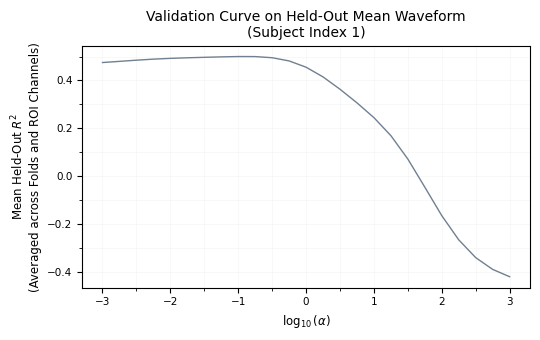

In [6]:
subj_inner_cv_valid_scores = [{float(alpha): float(obj.fold_scores[alpha].valid_mean)
                                            for alpha in obj.fold_scores}
                                            for obj in subj_tuned]
subj_idx = 1
fig, axes = plt.subplots(1, 1, figsize=(5.5, 3.5))
alphas_log = np.log10(list(subj_inner_cv_valid_scores[subj_idx].keys()))
axes.plot(alphas_log, list(subj_inner_cv_valid_scores[subj_idx].values()),
          color="slategrey", linewidth=1)
axes.tick_params(axis="both", which="major", labelsize=7.5)
axes.xaxis.set_minor_locator(AutoMinorLocator(2))
axes.yaxis.set_minor_locator(AutoMinorLocator(2))
axes.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1)
axes.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0)
axes.set_xlabel(r"$\log_{10}(\alpha)$", fontsize=8.5)
axes.set_ylabel(r"Mean Held-Out $R^2$"+"\n(Averaged across Folds and ROI Channels)", fontsize=8.5)
axes.set_title(f"Validation Curve on Held-Out Mean Waveform\n(Subject Index {subj_idx})", fontsize=10.0)
fig.tight_layout()

Per-subject refit in-sample R^2:
  [{'CZ': 0.9746527124239349, 'C3': 0.975835572824718, 'C4': 0.9721383518289798, 'CP3': 0.9752924131068578, 'CP4': 0.9731788088444661, 'CPZ': 0.9766048039113153}, {'CZ': 0.8967194437244123, 'C3': 0.9159248936487941, 'C4': 0.922954919423332, 'CP3': 0.892916369851684, 'CP4': 0.9128000115615734, 'CPZ': 0.8718789090398783}, {'CZ': 0.8799464005292567, 'C3': 0.8866645339320469, 'C4': 0.865134214405959, 'CP3': 0.8389684033943007, 'CP4': 0.8324672845171934, 'CPZ': 0.8435801806047665}, {'CZ': 0.9731025008272328, 'C3': 0.9841001961141856, 'C4': 0.9849103124674076, 'CP3': 0.9759354376621521, 'CP4': 0.9767364402041371, 'CPZ': 0.976758601448057}, {'CZ': 0.9214791081797825, 'C3': 0.9197365014429555, 'C4': 0.9099793365531648, 'CP3': 0.8844067569326574, 'CP4': 0.8943889228416172, 'CPZ': 0.9059304425777276}, {'CZ': 0.9206203341318947, 'C3': 0.9454989822826584, 'C4': 0.955181176230691, 'CP3': 0.9542623041781947, 'CP4': 0.9521577167741933, 'CPZ': 0.9183712171761594}, {'CZ

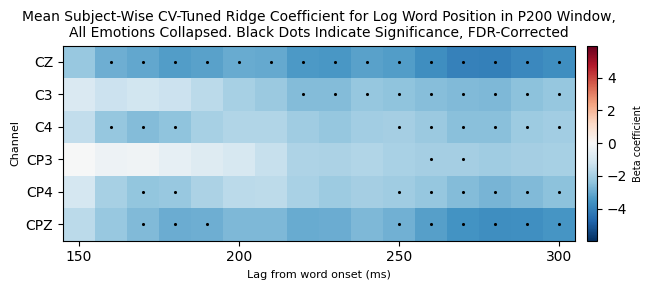

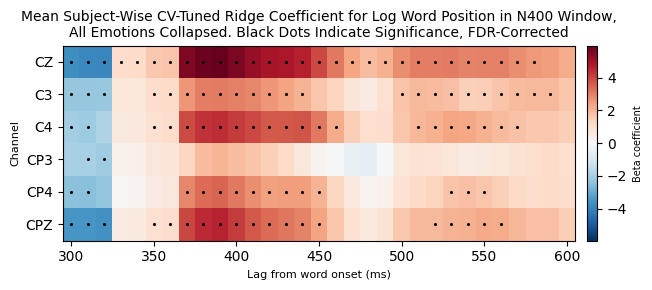

In [7]:
subj_refit_r2s = [s.r2 for s in subj_refit]
subj_best_alphas = [float(s.best_alpha) for s in subj_tuned]
subj_refit_alphas = [float(s.refit_alpha) for s in subj_refit]
print(f"Per-subject refit in-sample R^2:\n  {subj_refit_r2s}") # IMPORTANT: refit R^2 is IN-SAMPLE, hence totally normal to be high even if held-out validation R^2's are low during tuning!!
print(f"Per-subject best alpha:\n  {subj_best_alphas}")
print(f"Per-subject refit alpha (best alpha scaled by trial count):\n  {subj_refit_alphas}") # print to sanity check: should be equal to best alpha since score_on_mean=True

p200_coefs = get_time_window_coefs(subj_refit,
                                   n_predictors=2,
                                   intercept_index=0,
                                   beta_index=1,
                                   time_window=(0.15, 0.3),
                                   sfreq=100.0,
                                   sig_thresh=0.05)

n400_coefs = get_time_window_coefs(subj_refit,
                                   n_predictors=2,
                                   intercept_index=0,
                                   beta_index=1,
                                   time_window=(0.3, 0.6),
                                   sfreq=100.0,
                                   sig_thresh=0.05)

vmax = np.nanmax(np.abs(np.concatenate([p200_coefs.beta_window.mean(axis=0).ravel(),
                                        n400_coefs.beta_window.mean(axis=0).ravel()])))
vmin = -vmax
fig1 = time_window_heatmap(p200_coefs,
                           time_window=(0.15, 0.3),
                           dt=10,
                           ch_roi=ch_roi,
                           show_corrected=True,
                           vmin=vmin, vmax=vmax,
                           component_name="P200")
fig2 = time_window_heatmap(n400_coefs,
                           time_window=(0.3, 0.6),
                           dt=10,
                           ch_roi=ch_roi,
                           show_corrected=True,
                           vmin=vmin, vmax=vmax,
                           component_name="N400")
plt.show()

In [8]:
print("Refit summary: Per-subject channel-wise refit in-sample R^2 & refit alpha (alpha is selected across all channels during tuning, not channel-wise):")
refit_summary = pd.DataFrame(subj_refit_r2s)
refit_summary = refit_summary.rename(mapper=lambda x: f"R^2 ({x})", axis=1)
refit_summary.insert(0, "refit alpha", subj_refit_alphas)
display(refit_summary)

Refit summary: Per-subject channel-wise refit in-sample R^2 & refit alpha (alpha is selected across all channels during tuning, not channel-wise):


,refit alpha,R^2 (CZ),R^2 (C3),R^2 (C4),R^2 (CP3),R^2 (CP4),R^2 (CPZ)
0,0.003162,0.974653,0.975836,0.972138,0.975292,0.973179,0.976605
1,0.100000,0.896719,0.915925,0.922955,0.892916,0.912800,0.871879
2,0.316228,0.879946,0.886665,0.865134,0.838968,0.832467,0.843580
3,0.005623,0.973103,0.984100,0.984910,0.975935,0.976736,0.976759
4,0.177828,0.921479,0.919737,0.909979,0.884407,0.894389,0.905930
5,0.100000,0.920620,0.945499,0.955181,0.954262,0.952158,0.918371
6,0.100000,0.814429,0.784255,0.766099,0.836860,0.777158,0.769177
7,0.005623,0.950965,0.954313,0.940458,0.942246,0.948230,0.953777
8,0.001778,0.906873,0.927259,0.894787,0.858264,0.902470,0.893779
9,0.003162,0.928428,0.874467,0.925029,0.812688,0.888549,0.902732


mean = 0.054, std = 0.082, median = 0.004
min = 0.001, max = 0.316


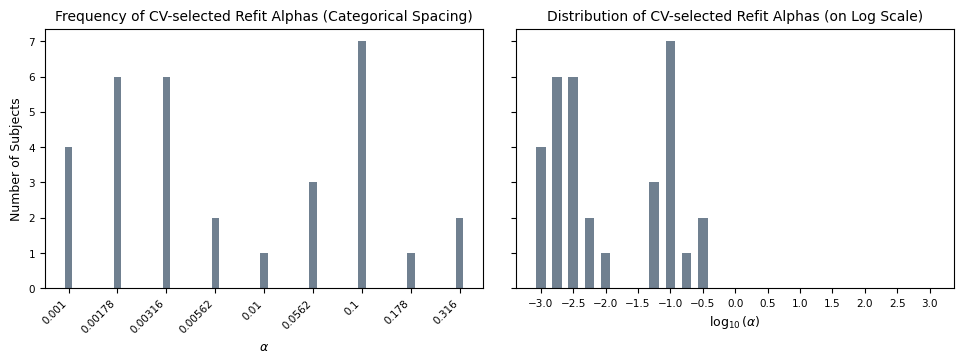

In [9]:
subj_refit_alphas = np.array(subj_refit_alphas)
print(f"mean = {round(np.mean(subj_refit_alphas), 3)}, std = {round(np.std(subj_refit_alphas), 3)}, median = {round(np.median(subj_refit_alphas), 3)}")
print(f"min = {round(np.min(subj_refit_alphas), 3)}, max = {round(np.max(subj_refit_alphas), 3)}")

alpha_counts = pd.Series(subj_refit_alphas).value_counts().reindex(alpha_range, fill_value=0).sort_index()
alpha_counts_non_zero = alpha_counts[alpha_counts > 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, sharex=False)
axes[0].bar(np.arange(len(alpha_counts_non_zero)),
            alpha_counts_non_zero.values,
            color="slategrey",
            width=0.15)
axes[1].bar(np.log10(alpha_counts.index),
            alpha_counts.values,
            color="slategrey",
            width=0.15)
axes[0].set_xlabel(r"$\alpha$", fontsize=9.0)
axes[1].set_xlabel(r"$\log_{10}(\alpha)$", fontsize=9.0)
for ax in axes:   
    ax.tick_params(axis="both", which="major", labelsize=7.5)

axes[0].set_ylabel("Number of Subjects", fontsize=9.0)
axes[0].set_title("Frequency of CV-selected Refit Alphas (Categorical Spacing)", fontsize=10.0)
axes[1].set_title("Distribution of CV-selected Refit Alphas (on Log Scale)", fontsize=10.0)

axes[0].set_xticks(np.arange(len(alpha_counts_non_zero)))
axes[0].set_xticklabels([f"{alpha:.3g}" for alpha in alpha_counts_non_zero.index],
                        rotation=45, ha="right")

axes[1].set_xticks(np.arange(-3, 3.1, 0.5))
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))

fig.tight_layout(pad=2)


In [46]:
# sensitivity analysis
subj_outer_scores = np.array([[subj_tuned[i].fold_scores[alpha].valid_mean
                                   for i in range(len(subj_tuned))] for alpha in alpha_range])
lambda_common = alpha_range[np.argmax(np.mean(subj_outer_scores, axis=1))]
subj_tuned_common, subj_refit_common = refit_all_subjs(epochs_iterable=list_of_epochs,
                                         evokeds_iterable=list_of_evokeds,
                                         matrices_iterable=list_of_matrices,
                                         matrix_refit=matrix_refit,
                                         ch_roi=ch_roi,
                                         alpha_range=None,
                                         lambda_common=lambda_common,
                                         score_on_mean=True,
                                         ssp=False, info=None,
                                         n_splits=5,
                                         ridge_tol=RIDGE_TOL, solver="auto", max_iter=MAX_ITER,
                                         verbose=True)
clear_output()
print("\nRefit done.")


Refit done.


lambda_common = 0.0031622776601683794


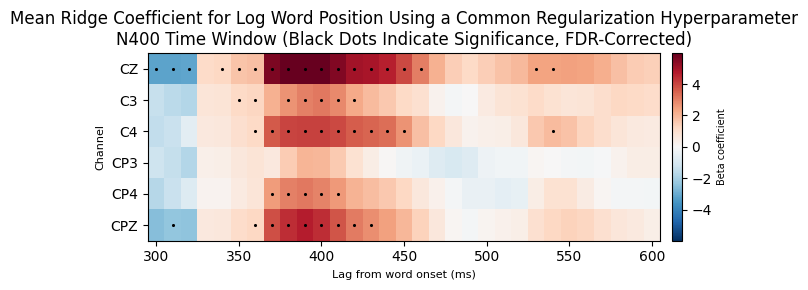

In [50]:
print(f"lambda_common = {lambda_common}")
n400_coefs_common = get_time_window_coefs(subj_refit_common,
                                   n_predictors=2,
                                   intercept_index=0,
                                   beta_index=1,
                                   time_window=(0.3, 0.6),
                                   sfreq=100.0,
                                   sig_thresh=0.05)
fig2_common = time_window_heatmap(n400_coefs_common,
                           time_window=(0.3, 0.6),
                           dt=10,
                           ch_roi=ch_roi,
                           show_corrected=True,
                           vmin=vmin, vmax=vmax,
                           alt_title=f"Mean Ridge Coefficient for Log Word Position Using a Common Regularization Hyperparameter\nN400 Time Window (Black Dots Indicate Significance, FDR-Corrected)",
                           component_name="N400")

In [17]:
def plot_waveforms(reconstruct: np.ndarray,
                   real_data: np.ndarray,
                   ch_roi: list, *,
                   decim: int,
                   figsize: tuple,
                   colors: list,
                   linewidth: float=0.75,
                   tick_labelsize: float=7.5,
                   xylabel_fontsize: float=10.5,
                   legend_bbox_to_anchor: list=[0.67, -0.06, 0.5, 0.5],
                   title_fontsize: float=13.0):
    assert reconstruct.shape == real_data.shape
    _, n_channels, n_times = reconstruct.shape
    assert len(ch_roi) == len(colors) == n_channels
    downsampled_times = np.linspace(0.0, n_times*decim, n_times)

    reconstruct_mean = np.mean(reconstruct, axis=0)
    real_data_mean = np.mean(real_data, axis=0)

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharey=True)
    for (j, ch), color in zip(enumerate(ch_roi), colors):
        axes[0].plot(downsampled_times, reconstruct_mean[j, :], linewidth=linewidth, label=ch, color=color)
        axes[1].plot(downsampled_times, real_data_mean[j, :], linewidth=linewidth, label=ch, color=color)
        axes[0].set_title("Reconstructed ERPs with Deconvolution (Words 1-7)\nAll Emotion Categories Collapsed",
                           y=1.02, fontsize=title_fontsize)
        axes[1].set_title("Grand Average ERPs (Words 1-7)\nAll Emotion Categories Collapsed",
                           y=1.02, fontsize=title_fontsize)
    for ax in axes:   
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1)
        ax.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0)
        ax.tick_params(axis="both", which="major", labelsize=tick_labelsize)
    axes[1].legend(bbox_to_anchor=legend_bbox_to_anchor)
    axes[1].set_ylabel("uV", fontsize=xylabel_fontsize, x=0.05)
    axes[1].set_xlabel("Time (ms)", fontsize=xylabel_fontsize, y=0.05)
    axes[1].invert_yaxis()

    fig.tight_layout()
    plt.show()

    

In [18]:
reconstruct = np.array([subj_refit[i].pred for i in range(len(subj_refit))])
real_data = np.array([e.get_data(units="uV", picks=ch_roi) for e in list_of_evokeds])
print(reconstruct.shape)
print(real_data.shape)

(32, 6, 257)
(32, 6, 257)


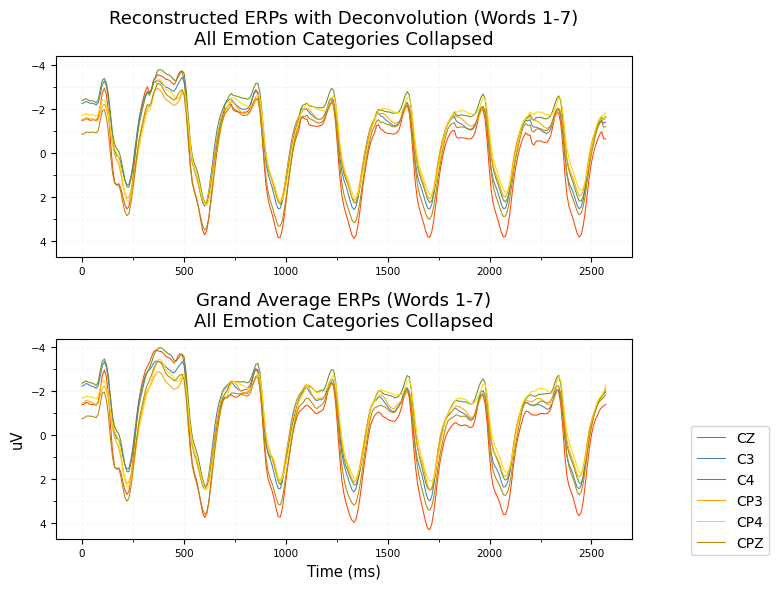

In [19]:
colors = ["orangered", "steelblue", "olivedrab", "orange", "gold", "darkgoldenrod"]
plot_waveforms(reconstruct,
               real_data,
               ch_roi,
               decim=10,
               figsize=(8, 6),
               colors=colors,
               linewidth=0.75,
               tick_labelsize=7.5,
               xylabel_fontsize=10.5,
               legend_bbox_to_anchor=[0.8, 0.15, 0.45, 0.45],
               title_fontsize=13.0)

### Separating emotion categories

> <strong>NOTE:</strong> $\downarrow$ Do not re-run this cell because `list_of_epochs` is mutated in-place.

In [52]:
time_lock_points = [x for x in pd.DataFrame(epochs.annotations)["description"] if x.startswith("w1/")]
assert len(time_lock_points) == total_n_trials
subj_conditions = [np.array([t.split("/")[1] for t in time_lock_points]) for _ in subj_drop_indices]
masks = [np.arange(1, total_n_trials+1) for _ in subj_drop_indices]
for mask, indices, conditions in zip(masks, subj_drop_indices, subj_conditions):
    mask[indices] = 0
    conditions[mask==0] = "-"

subj_condition_counts = [[np.sum(conditions==c) for c in ("neu", "pos", "neg")]
                                                for conditions in subj_conditions]
table = pd.DataFrame(data=subj_condition_counts,
                     columns=["neu %", "pos %", "neg %"])
table = table.astype(float)

def get_frac(x, col):
    my_d = {"neu %": 102, "pos %": 50, "neg %": 52} # total trial count per condition is hard coded here... lol
    return (1 - x/my_d[col]) * 100
for col in ["neu %", "pos %", "neg %"]:
    table[col] = table[col].map(get_frac, col=col)

table.insert(0, "ids", subj_ids)
table["ids"] = table["ids"].astype(str)
to_drop = table.loc[(table["neu %"] > DROP_PERCENTAGE_THRESHOLD)
                   |(table["pos %"] > DROP_PERCENTAGE_THRESHOLD)
                   |(table["neg %"] > DROP_PERCENTAGE_THRESHOLD)]
display(to_drop)
for idx in to_drop.index:
    list_of_epochs.pop(idx)
print(f"Remaining number of subjects = {len(list_of_epochs)}")



,ids,neu %,pos %,neg %
13,subj016,5.882353,24.0,11.538462


Remaining number of subjects = 31


In [53]:
emotions = ["neu", "pos", "neg"]
emotions_for_display = {"neu": "NEUTRAL", "pos": "POSITIVE", "neg": "NEGATIVE"}

arr_of_epochs_with_emo = [[e[f"w1/{emotions[0]}"], e[f"w1/{emotions[1]}"], e[f"w1/{emotions[2]}"]]
                                      for e in list_of_epochs]
arr_of_evokeds_with_emo = [[e.average(method="mean",
                                      by_event_type=False) for e in sublist]
                                      for sublist in arr_of_epochs_with_emo]
arr_of_epochs_with_emo = np.array(arr_of_epochs_with_emo, dtype=object)
arr_of_evokeds_with_emo = np.array(arr_of_evokeds_with_emo, dtype=object)

arr_of_matrices_with_emo = np.empty(arr_of_epochs_with_emo.shape, dtype=object)
arr_of_matrices_with_emo_perm = np.empty(arr_of_epochs_with_emo.shape, dtype=object)
for i in range(arr_of_epochs_with_emo.shape[0]):
    for j in range(arr_of_epochs_with_emo.shape[1]):
        arr_of_matrices_with_emo[i, j] = build_design(soa=SOA,
                                                      sfreq=DOWNSAMPLE_SFREQ,
                                                      n_words=N_WORDS, n_trials=len(arr_of_epochs_with_emo[i, j]),
                                                      response_lag=0.7,
                                                      rank_tol=1e-2,
                                                      intercept=True,
                                                      verbose=True,
                                                      word_pos=np.vstack([np.log(np.arange(1, N_WORDS+1))
                                                                          for _ in range(len(arr_of_epochs_with_emo[i, j]))]))
        arr_of_matrices_with_emo_perm[i, j] = build_design(soa=SOA,
                                                              sfreq=DOWNSAMPLE_SFREQ,
                                                              n_words=N_WORDS, n_trials=len(arr_of_epochs_with_emo[i, j]),
                                                              response_lag=0.7,
                                                              rank_tol=1e-2,
                                                              intercept=True,
                                                              verbose=True,
                                                              word_pos=np.vstack([np.log([4, 5, 1, 7, 2, 3, 6])
                                                                                  for _ in range(len(arr_of_epochs_with_emo[i, j]))]))
clear_output()
print(arr_of_epochs_with_emo.shape)
print(arr_of_evokeds_with_emo.shape)
print(arr_of_matrices_with_emo.shape)
print(arr_of_matrices_with_emo_perm.shape)

(31, 3)
(31, 3)
(31, 3)
(31, 3)


In [177]:
model_comparison_with_emo = dict()
for j in range(arr_of_epochs_with_emo.shape[1]):
    print(f"**EMOTION = {emotions_for_display[emotions[j]]}**")
    res = loop_over_subjs(epochs_iterable=arr_of_epochs_with_emo[:, j],
                          matrices_full_iterable=arr_of_matrices_with_emo[:, j],
                          matrices_restricted_iterable=None,
                          ch_roi=ch_roi,
                          alpha_range=alpha_range,
                          intercept_name="intercept",
                          ssp=False, info=None,
                          n_splits_outer=5, n_splits_inner=5,
                          verbose_subj_idx=True,
                          verbose_tuning=False)
    model_comparison_with_emo[emotions[j]] = res
    clear_output()
print("Done. Full model (inercept + word position) vs intercept-only, looped over all subjects and emotion categories.")

Done. Full model (inercept + word position) vs intercept-only, looped over all subjects and emotion categories.


In [95]:
model_comparison_with_emo_perm = dict()
for j in range(arr_of_epochs_with_emo.shape[1]):
    print(f"**EMOTION = {emotions_for_display[emotions[j]]}**")
    res = loop_over_subjs(epochs_iterable=arr_of_epochs_with_emo[:, j],
                          matrices_full_iterable=arr_of_matrices_with_emo_perm[:, j],
                          matrices_restricted_iterable=None,
                          ch_roi=ch_roi,
                          alpha_range=alpha_range,
                          intercept_name="intercept",
                          ssp=False, info=None,
                          n_splits_outer=5, n_splits_inner=5,
                          verbose_subj_idx=True,
                          verbose_tuning=False)
    model_comparison_with_emo_perm[emotions[j]] = res
    clear_output()
print("Done. Full model (inercept + word position PERM) vs intercept-only, looped over all subjects and emotion categories.")

Done. Full model (inercept + word position PERM) vs intercept-only, looped over all subjects and emotion categories.


In [ ]:
print("Full model (inercept + word position) vs intercept-only")
improve_dfs_with_emo = {key: compare_model_fit(model_comparison_with_emo[key].outer_scores_full_per_subj,
                                               model_comparison_with_emo[key].outer_scores_restricted_per_subj,
                                               ch_roi) for key in model_comparison_with_emo}
for key, df in improve_dfs_with_emo.items():
    print(f"**EMOTIONS = {emotions_for_display[key]}**")
    display(df)

**EMOTIONS = NEUTRAL**


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.072696,0.058729,0.013967,2.968011,0.002920,0.008761
C3,0.061554,0.050177,0.011377,2.653992,0.006300,0.010387
C4,0.060921,0.048555,0.012366,2.481874,0.009447,0.010387
CP3,0.051914,0.042069,0.009845,2.440754,0.010387,0.010387
CP4,0.049976,0.040031,0.009945,2.505930,0.008934,0.010387
CPZ,0.057844,0.047556,0.010288,3.200381,0.001618,0.008761


**EMOTIONS = POSITIVE**


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.052583,0.039666,0.012917,2.398427,0.011444,0.022004
C3,0.047838,0.037002,0.010836,2.288269,0.014670,0.022004
C4,0.040594,0.027526,0.013067,2.388677,0.011701,0.022004
CP3,0.033585,0.024071,0.009514,2.180248,0.018609,0.022330
CP4,0.031286,0.022507,0.008779,2.056345,0.024269,0.024269
CPZ,0.037502,0.027581,0.009921,2.494365,0.009177,0.022004


**EMOTIONS = NEGATIVE**


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.066809,0.051894,0.014915,2.409938,0.011147,0.029399
C3,0.054162,0.042740,0.011422,2.042681,0.024979,0.029399
C4,0.051286,0.038901,0.012385,2.059623,0.024102,0.029399
CP3,0.044704,0.034495,0.010208,2.017231,0.026348,0.029399
CP4,0.038490,0.029726,0.008764,1.964479,0.029399,0.029399
CPZ,0.050607,0.039291,0.011316,2.462119,0.009889,0.029399


In [96]:
print("Full model (inercept + PERMUTED word position) vs intercept-only")
improve_dfs_with_emo_perm = {key: compare_model_fit(model_comparison_with_emo_perm[key].outer_scores_full_per_subj,
                                               model_comparison_with_emo_perm[key].outer_scores_restricted_per_subj,
                                               ch_roi) for key in model_comparison_with_emo_perm}
for key, df in improve_dfs_with_emo_perm.items():
    print(f"**EMOTIONS = {emotions_for_display[key]}**")
    display(df)

Full model (inercept + PERMUTED word position) vs intercept-only
**EMOTIONS = NEUTRAL**


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.058478,0.058729,-0.000251,-0.538588,0.702927,0.99831
C3,0.049516,0.050178,-0.000662,-2.023752,0.974009,0.99831
C4,0.047829,0.048553,-0.000724,-2.070655,0.976454,0.99831
CP3,0.041112,0.042076,-0.000963,-3.183468,0.998310,0.99831
CP4,0.039215,0.040018,-0.000803,-2.126851,0.979115,0.99831
CPZ,0.047195,0.047557,-0.000361,-0.709820,0.758351,0.99831


**EMOTIONS = POSITIVE**


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.039248,0.039711,-0.000463,-0.500111,0.689677,0.997062
C3,0.035111,0.037032,-0.001921,-2.965553,0.997062,0.997062
C4,0.026500,0.027550,-0.001049,-1.470081,0.924025,0.997062
CP3,0.022301,0.024066,-0.001766,-2.765977,0.995190,0.997062
CP4,0.021316,0.022373,-0.001056,-1.282694,0.895289,0.997062
CPZ,0.026798,0.027600,-0.000802,-0.857382,0.800984,0.997062


**EMOTIONS = NEGATIVE**


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.049631,0.051887,-0.002256,-3.411089,0.999066,0.999964
C3,0.040508,0.042729,-0.002222,-4.110235,0.999859,0.999964
C4,0.036823,0.038867,-0.002044,-3.120048,0.998012,0.999964
CP3,0.032140,0.034486,-0.002347,-4.601983,0.999964,0.999964
CP4,0.027659,0.029712,-0.002053,-3.117534,0.997999,0.999964
CPZ,0.037264,0.039291,-0.002027,-3.104793,0.997933,0.999964


In [13]:
refit_with_emo = dict()
for j in range(arr_of_epochs_with_emo.shape[1]):
    print(f"**EMOTION = {emotions_for_display[emotions[j]]}**")
    res = refit_all_subjs(epochs_iterable=arr_of_epochs_with_emo[:, j],
                          evokeds_iterable=arr_of_evokeds_with_emo[:, j],
                          matrices_iterable=arr_of_matrices_with_emo[:, j],
                          matrix_refit=matrix_refit,
                          ch_roi=ch_roi,
                          alpha_range=alpha_range,
                          lambda_common=None,
                          score_on_mean=True,
                          ssp=False, info=None,
                          n_splits=5,
                          ridge_tol=RIDGE_TOL, solver="auto", max_iter=MAX_ITER,
                          verbose=True)
    refit_with_emo[emotions[j]] = res
    
    clear_output()
print("Refit done, all three emotion conditions.")

Refit done, all three emotion conditions.


,neu,pos,neg
count,31.000000,31.000000,31.000000
mean,0.187363,33.349637,0.926789
std,0.182071,179.430220,1.964552
min,0.001000,0.001778,0.003162
25%,0.004393,0.177828,0.247028
50%,0.177828,0.316228,0.316228
75%,0.316228,1.000000,0.781171
max,0.562341,1000.000000,10.000000


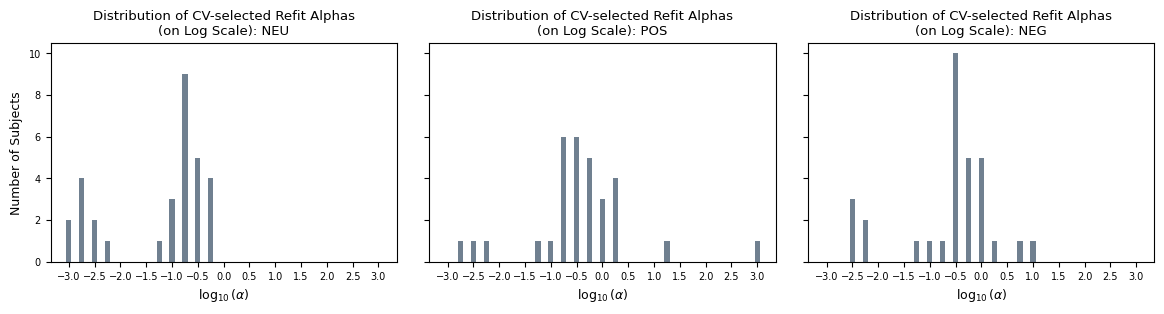

In [41]:
inspect_refit_alphas = pd.DataFrame({emo: [float(obj.refit_alpha) for obj in refit_with_emo[emo][1]]
                                                                  for emo in emotions})
display(inspect_refit_alphas.describe())

alpha_counts_dict = [dict(inspect_refit_alphas[emo].value_counts()) for emo in emotions]
alpha_counts_dict = [{np.log10(k): int(v) for k, v in d.items()} for d in alpha_counts_dict]
to_merge = [{k: 0 for k in np.log10(alpha_range) if k not in d} for d in alpha_counts_dict]
alpha_counts_dict = [pd.Series((d | m)).sort_index() for d, m in zip(alpha_counts_dict, to_merge)]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True, sharex=True)
for ax, d, emo in zip(axes, alpha_counts_dict, emotions):
    ax.bar(d.index,
           d.values,
           color="slategrey",
           width=0.1)
    ax.set_xlabel(r"$\log_{10}(\alpha)$", fontsize=9.0)
    ax.tick_params(axis="both", which="major", labelsize=7.0)
    ax.set_title(f"Distribution of CV-selected Refit Alphas\n(on Log Scale): {emo.upper()}", fontsize=9.5)
    ax.set_xticks(np.arange(-3, 3.1, 0.5))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].set_ylabel("Number of Subjects", fontsize=9.0)
fig.tight_layout(pad=2)


In [144]:
dfs = {emo: pd.DataFrame([obj.r2 for obj in refit_with_emo[emo][1]])
                                  for emo in emotions}
display(dfs["neg"])

,CZ,C3,C4,CP3,CP4,CPZ
0,0.727793,0.676167,0.725157,0.701667,0.727294,0.763820
1,0.761767,0.766150,0.778870,0.710511,0.759896,0.701429
2,0.822325,0.761346,0.784691,0.742340,0.731699,0.784621
3,0.925638,0.914727,0.892861,0.888194,0.874591,0.922083
4,0.835452,0.849751,0.823516,0.816562,0.786633,0.814719
5,0.746896,0.770317,0.719842,0.778994,0.730306,0.747979
6,0.680758,0.524804,0.533421,0.621113,0.624103,0.590180
7,0.771750,0.776239,0.771086,0.765466,0.807007,0.788651
8,0.635118,0.683711,0.629392,0.676730,0.714330,0.709491
9,0.549013,0.531828,0.599219,0.311443,0.429026,0.434447


In [42]:
# sensitivity analysis
subj_outer_scores = np.array([[subj_tuned[i].fold_scores[alpha].valid_mean
                                   for i in range(len(subj_tuned))] for alpha in alpha_range])
lambda_common = alpha_range[np.argmax(np.mean(subj_outer_scores, axis=1))]

refit_with_emo_lambda_common = dict()
for j in range(arr_of_epochs_with_emo.shape[1]):
    print(f"**EMOTION = {emotions_for_display[emotions[j]]}**")
    res = refit_all_subjs(epochs_iterable=arr_of_epochs_with_emo[:, j],
                          evokeds_iterable=arr_of_evokeds_with_emo[:, j],
                          matrices_iterable=arr_of_matrices_with_emo[:, j],
                          matrix_refit=matrix_refit,
                          ch_roi=ch_roi,
                          alpha_range=None,
                          lambda_common=lambda_common, 
                          ssp=False, info=None,
                          n_splits=5,
                          ridge_tol=RIDGE_TOL, solver="auto", max_iter=MAX_ITER,
                          verbose=True)
    refit_with_emo_lambda_common[emotions[j]] = res
    
    clear_output()
print("Refit with `lambda_common = np.median(subj_refit_alphas)` done , all three emotion conditions.")

Refit with `lambda_common = np.median(subj_refit_alphas)` done , all three emotion conditions.


In [146]:
dfs_lambda_common = {emo: pd.DataFrame([obj.r2 for obj in refit_with_emo_lambda_common[emo][1]])
                                               for emo in emotions}
display(dfs_lambda_common["neg"])

,CZ,C3,C4,CP3,CP4,CPZ
0,0.927420,0.932352,0.919048,0.930001,0.906603,0.944142
1,0.814143,0.810640,0.820564,0.760260,0.804879,0.758010
2,0.835453,0.771263,0.805888,0.753232,0.758457,0.802776
3,0.945745,0.943415,0.920573,0.920531,0.904871,0.942561
4,0.904858,0.910171,0.892356,0.877490,0.865845,0.886493
5,0.827848,0.863551,0.825018,0.863459,0.825785,0.828758
6,0.765259,0.665918,0.724459,0.714182,0.755550,0.698877
7,0.877685,0.879387,0.869403,0.869078,0.889702,0.877023
8,0.799653,0.810868,0.782571,0.720147,0.794540,0.780057
9,0.738639,0.685711,0.724492,0.616826,0.657482,0.667470


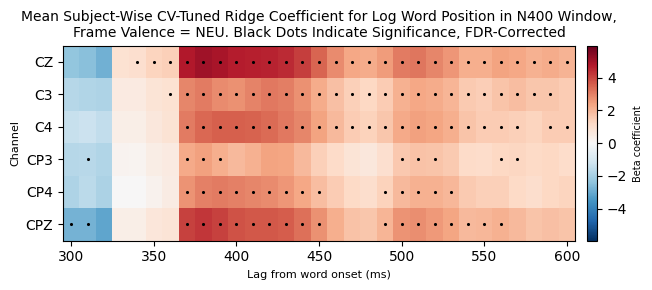

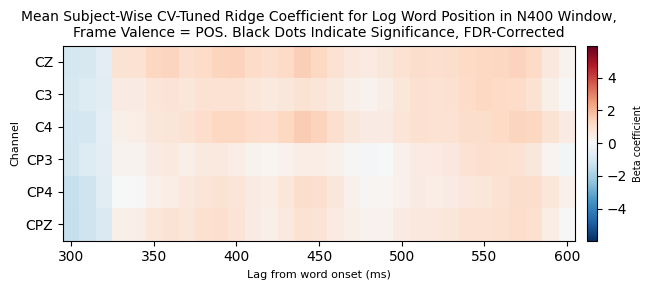

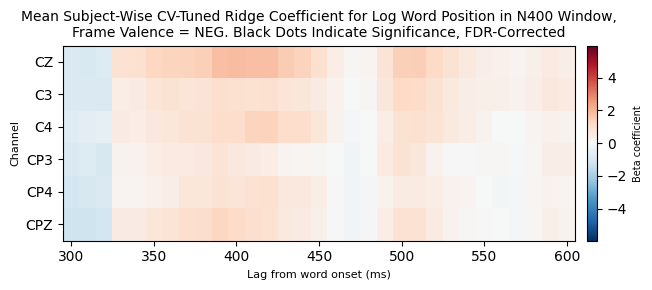

In [43]:
n400_coefs_with_emo = {key: get_time_window_coefs(val[1],
                                                  n_predictors=2,
                                                  intercept_index=0,
                                                  beta_index=1,
                                                  time_window=(0.3, 0.6),
                                                  sfreq=100.0,
                                                  sig_thresh=0.05)
                                                  for key, val in refit_with_emo.items()}
figs_with_emo = {key: time_window_heatmap(coefs,
                                          time_window=(0.3, 0.6),
                                          dt=10,
                                          ch_roi=ch_roi,
                                          show_corrected=True,
                                          vmin=-vmin, vmax=vmax,
                                          component_name="N400",
                                          emotion_category=f"Frame Valence = {key.upper()}")
                                          for key, coefs in n400_coefs_with_emo.items()}

Sensitivity analysis: using `lambda_common = np.mean(subj_refit_alphas)` from collapsed emotions.


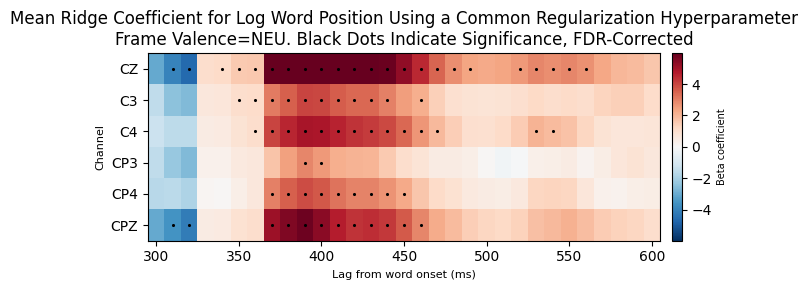

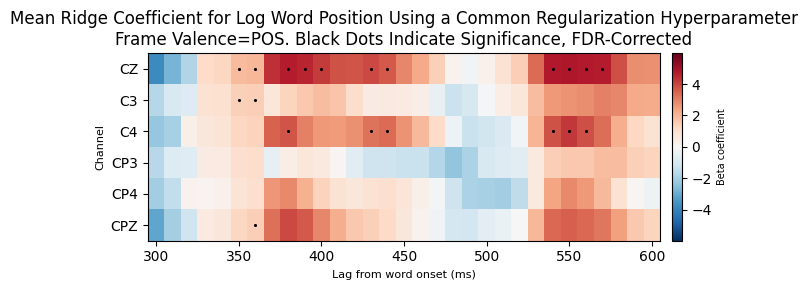

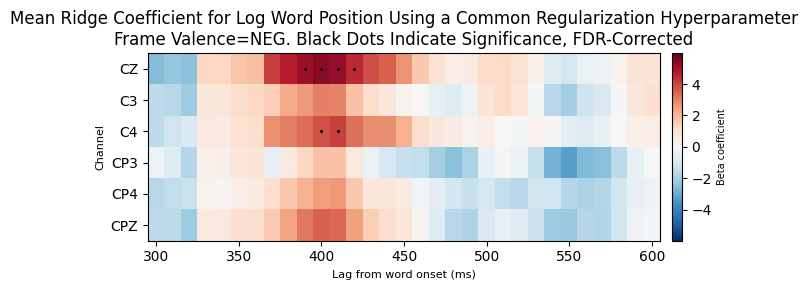

In [45]:
print("Sensitivity analysis: using `lambda_common = np.mean(subj_refit_alphas)` from collapsed emotions.")
n400_coefs_with_emo_lambda_common = {key: get_time_window_coefs(val[1],
                                                  n_predictors=2,
                                                  intercept_index=0,
                                                  beta_index=1,
                                                  time_window=(0.3, 0.6),
                                                  sfreq=100.0,
                                                  sig_thresh=0.05)
                                                  for key, val in refit_with_emo_lambda_common.items()}
figs_with_emo_lambda_common = {key: time_window_heatmap(coefs,
                                          time_window=(0.3, 0.6),
                                          dt=10,
                                          ch_roi=ch_roi,
                                          show_corrected=True,
                                          vmin=-vmin, vmax=vmax,
                                          component_name="N400",
                                          alt_title=f"Mean Ridge Coefficient for Log Word Position Using a Common Regularization Hyperparameter\nFrame Valence={key.upper()}. Black Dots Indicate Significance, FDR-Corrected")
                                          for key, coefs in n400_coefs_with_emo_lambda_common.items()}

In [ ]:
# do both pooled emotion (pos + neg) and undersample neu

# for every subject and emotion category, save total_n_trials, alpha, alpha/total_n_trials
# compare the distribution og log(alpha/total_n_trials) across neu, pos, neg
# also inspect the complete inner-CV score curve across alpha.
# A selected alpha is not stable when all there are many other candidates with virtually indistinguishable scores

# the most informative sensitivity analysis: use a common lambda_common for neu, pos, neg
# to fit to the trial mean 
# if score_on_mean=False (i.e., stacked fitting), the estimated coefficients will be equivalent to alpha = total_n_trtials * lambda_common
# then inspect if coefficients for pos and neg remain substantially smaller than neu when regularization strength is held constant
# if the difference disappears, then differntial shrinkage due to trial count imbalance is largely the culprit
# if the difference persists, this supports genuine conditional difference



# for wave 2, do rERP for sanity check (separate neu, pos, emo)